# Transformação estabilizadora da variância
É um processo em modelagem onde temos uma variável $X$ extraída de uma distribuição $P$. E temos que $\mathbb{E}_P[X] = \mu$ e $\mathbb{V}_P[X] = f(\mu)$. Isso acaba por atrapalhar nossos cálculos em intervalos de confiança para a média, pois, muitas vezes, eles dependem de que a variância seja **constante**

Exemplo:
$$
    X \sim Poisson(\lambda) \Rightarrow \mathbb{E}[X] = \lambda, \mathbb{V}[X] = \lambda
$$
usando a função $f(X) = \sqrt{X}$ e aplicando o método delta, temos que:
$$
    \mathbb{V}[X] \approx (f'(\lambda))^2 \space \mathbb{V}[X] = \frac{1}{4 \lambda} \lambda = \frac{1}{4}
$$

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import poisson

In [36]:
lambd = 5
n = 10000
sample = np.random.poisson(lam=lambd, size=n)

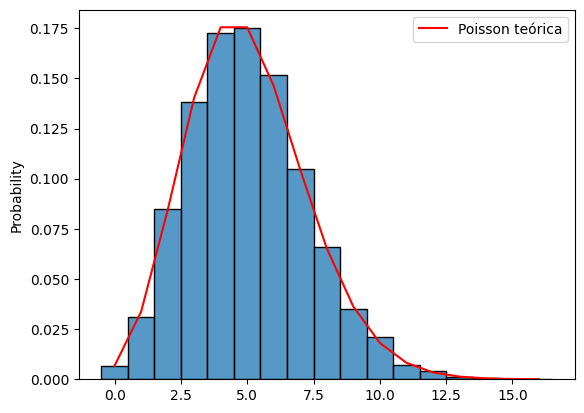

In [37]:
sns.histplot(sample, stat="probability", discrete=True)

k_vals = np.arange(0, max(sample) + 1)
pmf = poisson.pmf(k_vals, mu=lambd)

plt.plot(k_vals, pmf, color='red', label='Poisson teórica')

plt.legend()
plt.show()

In [38]:
# Estimando a variância da amostra
sample_variance = np.var(sample, ddof=1)
sample_mean = np.mean(sample)
sample_mean, sample_variance

(np.float64(5.0358), np.float64(5.018020162016201))

In [39]:
# Aplicando a transformação
transformed_sample = np.sqrt(sample)
sample_variance = np.var(transformed_sample, ddof=1)
sample_mean = np.mean(transformed_sample)
sample_mean, sample_variance

(np.float64(2.1798461183795066), np.float64(0.28409931011681006))